In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
data = {
    "Age": ["Young","Young","Young","Young","Middle","Middle","Middle","Middle",
            "Senior","Senior","Senior","Senior","Young","Middle","Senior",
            "Young","Middle","Senior"],

    "Income": [25,40,70,90,30,50,80,95,35,55,75,100,45,85,60,88,32,78],

    "Credit_Score": [580,620,720,800,590,650,710,790,600,660,730,820,
                     640,750,670,810,610,740],

    "Employment": ["Unemployed","Private","Government","Self",
                   "Private","Government","Self","Unemployed",
                   "Government","Self","Private","Unemployed",
                   "Private","Government","Self","Private",
                   "Unemployed","Government"],

    "Property": ["Rent","Own","Mortgage","Own","Rent","Mortgage","Own","Rent",
                 "Mortgage","Rent","Own","Mortgage","Rent","Own",
                 "Mortgage","Own","Rent","Mortgage"],

    "Loan_Approved": ["No","No","Yes","Yes","No","Yes","Yes","No",
                      "No","Yes","Yes","No","No","Yes","Yes",
                      "Yes","No","Yes"]
}

df = pd.DataFrame(data)
df


,Age,Income,Credit_Score,Employment,Property,Loan_Approved
0,Young,25,580,Unemployed,Rent,No
1,Young,40,620,Private,Own,No
2,Young,70,720,Government,Mortgage,Yes
3,Young,90,800,Self,Own,Yes
4,Middle,30,590,Private,Rent,No
5,Middle,50,650,Government,Mortgage,Yes
6,Middle,80,710,Self,Own,Yes
7,Middle,95,790,Unemployed,Rent,No
8,Senior,35,600,Government,Mortgage,No
9,Senior,55,660,Self,Rent,Yes


In [ ]:
def entropy(target):
    values, counts = np.unique(target, return_counts=True)
    probabilities = counts / counts.sum()
    return -np.sum(probabilities * np.log2(probabilities))


In [ ]:
def information_gain(data, feature, target):

    total_entropy = entropy(data[target])

    # If numeric feature → find best threshold
    if np.issubdtype(data[feature].dtype, np.number):

        sorted_values = np.sort(data[feature].unique())
        thresholds = (sorted_values[:-1] + sorted_values[1:]) / 2

        best_gain = 0
        best_threshold = None

        for threshold in thresholds:
            left = data[data[feature] <= threshold]
            right = data[data[feature] > threshold]

            weight = (len(left)/len(data))*entropy(left[target]) + \
                     (len(right)/len(data))*entropy(right[target])

            gain = total_entropy - weight

            if gain > best_gain:
                best_gain = gain
                best_threshold = threshold

        return best_gain, best_threshold

    else:
        # Categorical
        values, counts = np.unique(data[feature], return_counts=True)

        weighted_entropy = 0
        for v, c in zip(values, counts):
            subset = data[data[feature] == v]
            weighted_entropy += (c/len(data)) * entropy(subset[target])

        return total_entropy - weighted_entropy, None


In [ ]:
def gain_ratio(data, feature, target):

    ig, threshold = information_gain(data, feature, target)

    if np.issubdtype(data[feature].dtype, np.number):
        if threshold is None:
            return 0, None

        left = data[data[feature] <= threshold]
        right = data[data[feature] > threshold]

        split_info = -(
            (len(left)/len(data))*np.log2(len(left)/len(data)) +
            (len(right)/len(data))*np.log2(len(right)/len(data))
        )
    else:
        values, counts = np.unique(data[feature], return_counts=True)
        split_info = -np.sum((counts/len(data)) * np.log2(counts/len(data)))

    if split_info == 0:
        return 0, None

    return ig/split_info, threshold


In [ ]:
def build_tree(data, features, target, depth=0, max_depth=3):

    if len(np.unique(data[target])) == 1:
        return data[target].iloc[0]

    if depth >= max_depth or len(features) == 0:
        return data[target].mode()[0]

    best_feature = None
    best_ratio = 0
    best_threshold = None

    for feature in features:
        ratio, threshold = gain_ratio(data, feature, target)
        if ratio > best_ratio:
            best_ratio = ratio
            best_feature = feature
            best_threshold = threshold

    tree = {best_feature: {}}

    if best_threshold is not None:  # Numeric
        left = data[data[best_feature] <= best_threshold]
        right = data[data[best_feature] > best_threshold]

        remaining = [f for f in features if f != best_feature]

        tree[best_feature]["<= "+str(round(best_threshold,2))] = \
            build_tree(left, remaining, target, depth+1, max_depth)

        tree[best_feature]["> "+str(round(best_threshold,2))] = \
            build_tree(right, remaining, target, depth+1, max_depth)

    else:  # Categorical
        for value in data[best_feature].unique():
            subset = data[data[best_feature] == value]
            remaining = [f for f in features if f != best_feature]

            tree[best_feature][value] = \
                build_tree(subset, remaining, target, depth+1, max_depth)

    return tree


In [ ]:
features = df.columns[:-1]
target = "Loan_Approved"

tree = build_tree(df, features, target, max_depth=3)

tree


{'Income': {'<= 47.5': 'No',
  '> 47.5': {'Credit_Score': {'<= 770.0': 'Yes',
    '> 770.0': {'Age': {'Young': 'Yes', 'Middle': 'No', 'Senior': 'No'}}}}}}

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def draw_tree_with_entropy(tree, data, target):

    fig, ax = plt.subplots(figsize=(15,9))
    ax.set_ylim(0, 1)
    ax.axis('off')

    box_style = dict(boxstyle="round,pad=0.5", fc="#FFD54F", ec="black")

    # -------- Entropy Function --------
    def entropy(target_values):
        values, counts = np.unique(target_values, return_counts=True)
        probs = counts / counts.sum()
        return -np.sum(probs * np.log2(probs + 1e-9))

    # -------- Count leaf nodes (for spacing) --------
    def count_leaves(subtree):
        if not isinstance(subtree, dict):
            return 1
        feature = list(subtree.keys())[0]
        return sum(count_leaves(child) for child in subtree[feature].values())

    total_leaves = count_leaves(tree)
    ax.set_xlim(0, total_leaves)

    # -------- Recursive Plot --------
    def plot_tree(subtree, dataset, x_min, x_max, y, level_gap=0.22):

        x_center = (x_min + x_max) / 2

        node_entropy = round(entropy(dataset[target]), 3)

        # Leaf node
        if not isinstance(subtree, dict):
            label = f"{subtree}\n(H = {node_entropy})"
            ax.text(x_center, y, label,
                    ha='center', va='center',
                    bbox=box_style, fontsize=10, fontweight='bold')
            return

        feature = list(subtree.keys())[0]
        children = subtree[feature]

        label = f"{feature}\n(H = {node_entropy})"

        ax.text(x_center, y, label,
                ha='center', va='center',
                bbox=box_style, fontsize=10, fontweight='bold')

        current_x = x_min

        for value, child in children.items():

            # Split dataset according to branch
            if "<=" in value:
                threshold = float(value.split("<= ")[1])
                subset = dataset[dataset[feature] <= threshold]
            elif ">" in value:
                threshold = float(value.split("> ")[1])
                subset = dataset[dataset[feature] > threshold]
            else:
                subset = dataset[dataset[feature] == value]

            leaf_count = count_leaves(child)
            child_x_min = current_x
            child_x_max = current_x + leaf_count
            child_x_center = (child_x_min + child_x_max) / 2

            # Draw edge
            ax.plot([x_center, child_x_center],
                    [y-0.04, y-level_gap+0.04])

            ax.text((x_center + child_x_center)/2,
                    (y + (y-level_gap))/2,
                    str(value),
                    fontsize=9,
                    ha='center')

            plot_tree(child,
                      subset,
                      child_x_min,
                      child_x_max,
                      y - level_gap,
                      level_gap)

            current_x += leaf_count

    plot_tree(tree, data, 0, total_leaves, 0.92)
    plt.show()


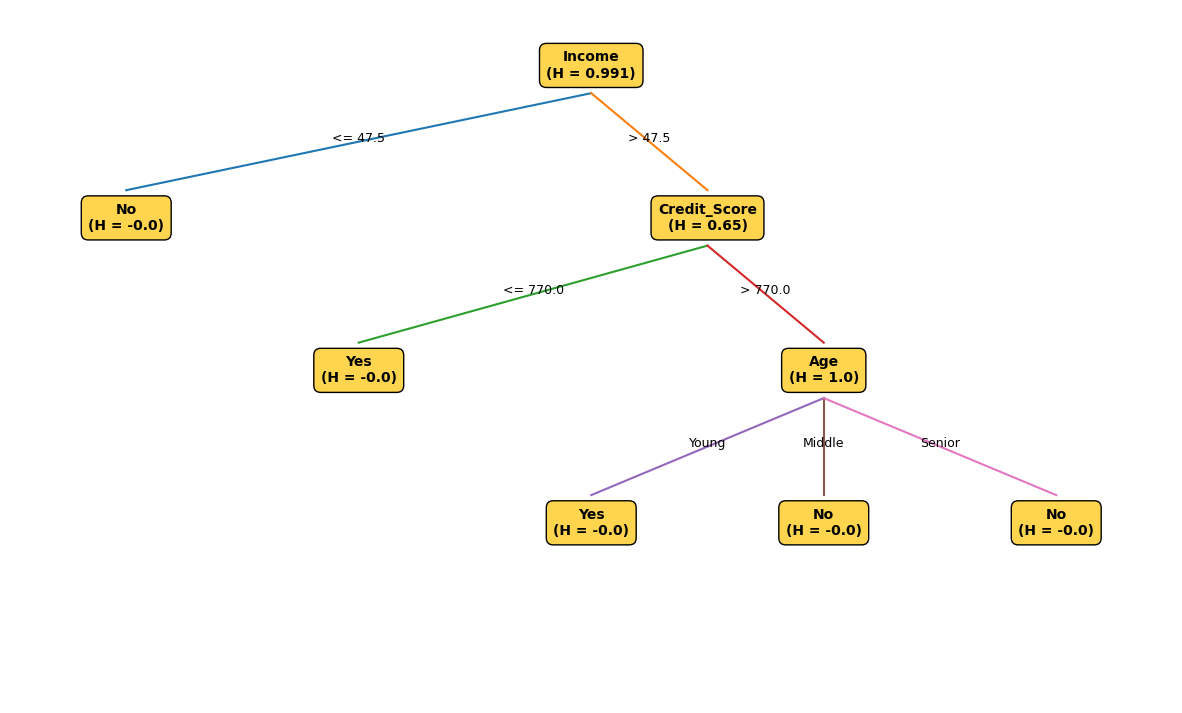

In [ ]:
draw_tree_with_entropy(tree, df, "Loan_Approved")
